### Data Understanding

#### ***Goal:*** Load the data, inspect structure, validate schema, and document initial findings.Before writing any model code, we need to understand what we're working with.

In [41]:
import pandas as pd
import numpy as np
import sys
sys.path.insert(0, "../src")
from housing.data.load_data import load_raw_data, load_config, validate_schema, check_duplicates

#### 1. Load Configuration and Data

In [42]:
config = load_config("../config/config.yaml")
df = load_raw_data("../data/raw/housing.csv")
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDuplicated rows: {df.duplicated().sum()}")

INFO:housing.data.load_data:Loaded 500 rows from ../data/raw/housing.csv


Shape: (500, 6)

Columns:
square_feet      int64
bedrooms         int64
bathrooms      float64
age            float64
location        object
price          float64
dtype: object

Missing values:
square_feet     0
bedrooms        0
bathrooms       0
age            15
location        0
price           0
dtype: int64

Duplicated rows: 0


#### 2. Schema Validation Check that the data matches our expected schema before proceeding.

In [43]:
is_valid, errors = validate_schema(df, config)
if not is_valid:
    for e in errors:
        print(f"❌ {e}")
else:
    print("Schema validation passed")

INFO:housing.data.load_data:Schema validation passed.


Schema validation passed


#### 3. Quick Profile Look at distributions and ranges to spot any red flags.

In [44]:
print("\n=== NUMERIC SUMMARY ===")
print(df.describe())
print("\n=== CATEGORICAL DISTRIBUTION ===")
print(df['location'].value_counts())
print("\n=== RANGE CHECKS ===")
for col in df.select_dtypes(include=[np.number]).columns:
    print(f"{col}: min={df[col].min()}, max={df[col].max()}")


=== NUMERIC SUMMARY ===
       square_feet    bedrooms   bathrooms         age          price
count   500.000000  500.000000  500.000000  485.000000     500.000000
mean   2119.710000    2.468000    2.084000   24.550515  415675.600000
std     780.766715    0.847592    0.690578   13.694725  160445.057629
min     701.000000    1.000000    0.750000    1.000000   87400.000000
25%    1475.000000    2.000000    1.500000   14.000000  301325.000000
50%    2138.500000    3.000000    2.250000   23.000000  393450.000000
75%    2762.750000    3.000000    2.750000   36.000000  519250.000000
max    3499.000000    4.000000    3.500000   49.000000  851600.000000

=== CATEGORICAL DISTRIBUTION ===
location
Suburbs     239
Downtown    190
Rural        71
Name: count, dtype: int64

=== RANGE CHECKS ===
square_feet: min=701, max=3499
bedrooms: min=1, max=4
bathrooms: min=0.75, max=3.5
age: min=1.0, max=49.0
price: min=87400.0, max=851600.0


#### 4. Initial Observations Document what you see here before moving to 
EDA:- **Shape:** 500 rows, 6 columns- 
***Missing:*** Only `age` has missing values (15 rows, 3%)- 
***Duplicates:*** None- 
***Ranges:*** All look reasonable — no negative prices, no 0-bedroom homes- 
***Locations:*** Suburbs (48%), Downtown (38%), Rural (14%) ***Decision:*** Median imputation for age is appropriate. No extreme outliers to remove yet.

---# Part 2: EDA

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Add the src directory to Python's module search path
sys.path.insert(0, "../src")

# Import functions
from housing.data.load_data import load_raw_data
from housing.visualization.visualize import (
    plot_distributions,
    plot_correlation_matrix,
    plot_price_by_location
)

# Set plot style
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

# Load data
df = load_raw_data("../data/raw/housing.csv")

# Display the first 5 rows
print(df.head())

INFO:housing.data.load_data:Loaded 500 rows from ../data/raw/housing.csv


   square_feet  bedrooms  bathrooms   age  location     price
0         1560         2       2.00  42.0   Suburbs  226200.0
1         1994         2       1.50  30.0   Suburbs  307500.0
2         1830         2       1.50  16.0  Downtown  438500.0
3         1795         3       2.25  12.0   Suburbs  327100.0
4         2338         2       1.50  17.0  Downtown  542500.0


#### 1. Distribution Overview

INFO:housing.visualization.visualize:Saved distribution plot to ../reports/figures/eda_distributions.png


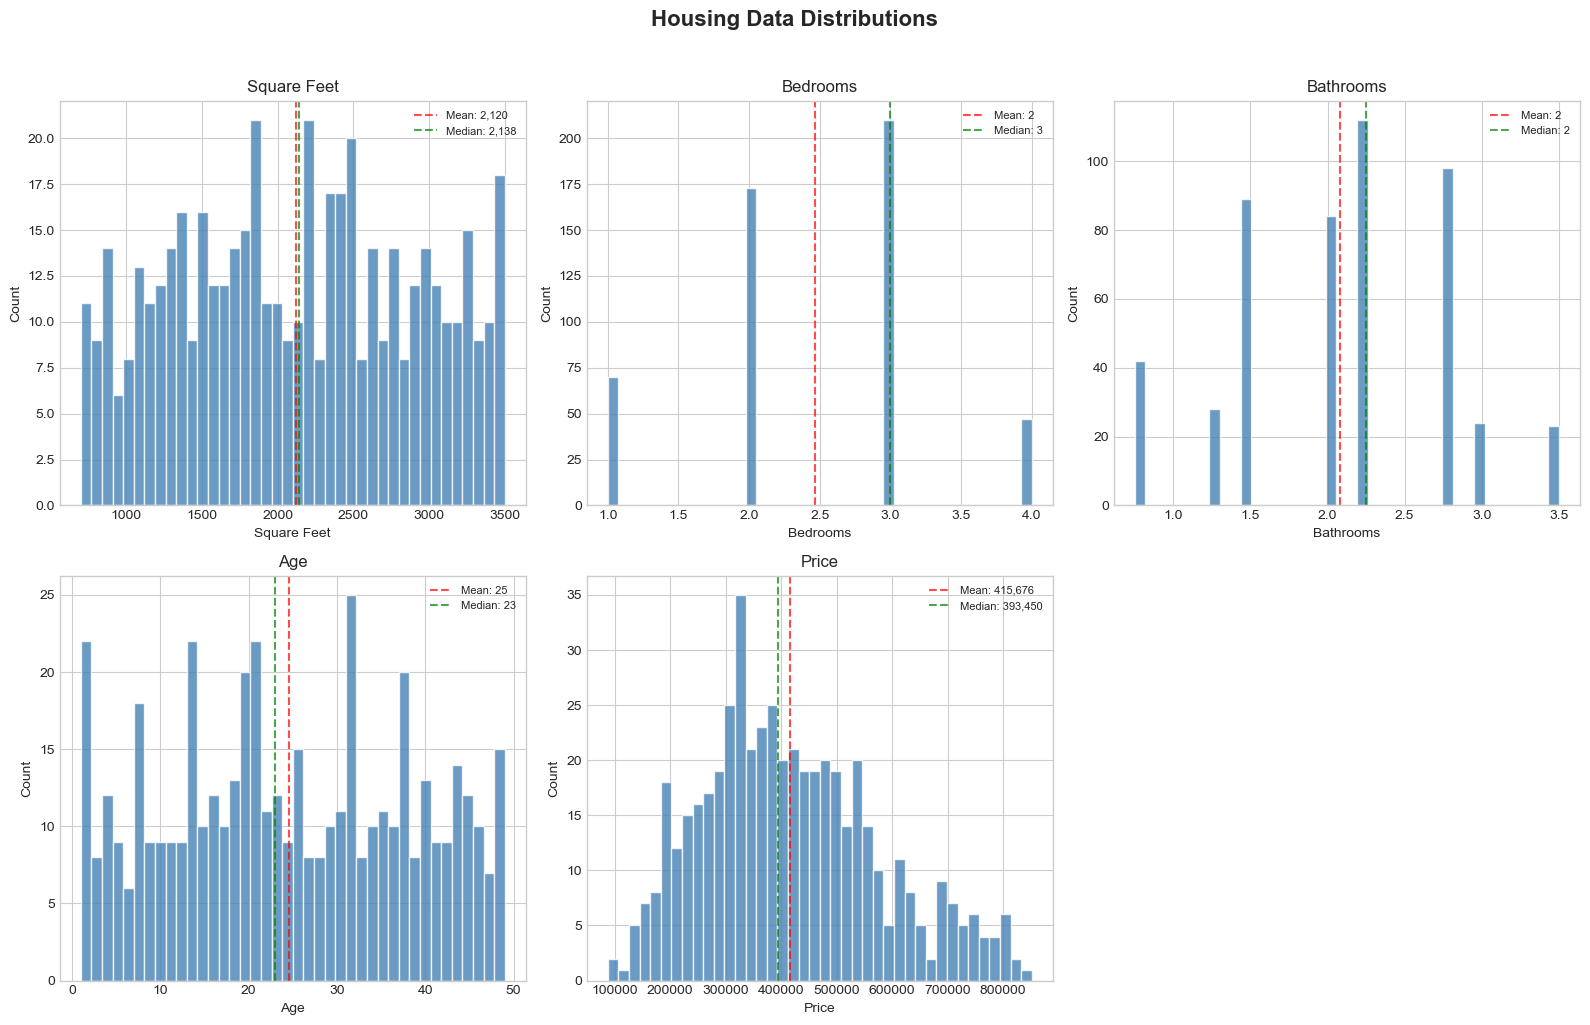

In [46]:
fig = plot_distributions(df, save_path="../reports/figures/eda_distributions.png")
plt.show()    

**Observations:**- Price is roughly right-skewed but not extreme- Square footage spans 701–3499 (good range)- Age is fairly uniform 1–49 years

#### 2. Correlation Analysis

INFO:housing.visualization.visualize:Saved correlation plot to ../reports/figures/eda_correlations.png


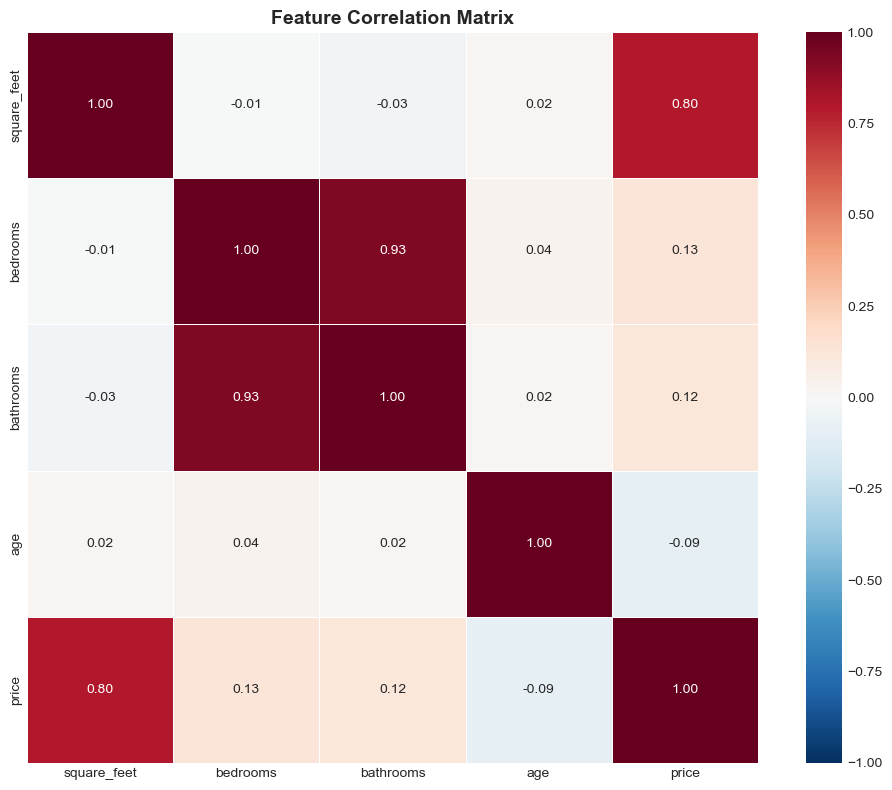

In [47]:
fig = plot_correlation_matrix(df, save_path="../reports/figures/eda_correlations.png")
plt.show()

**Key Correlations with Price:**- square_feet: **0.80** ← Dominant driver- bedrooms: 0.13- bathrooms: 0.12- age: **-0.09** ← Surprisingly weak!**Multicollinearity alert:** bedrooms and bathrooms are 0.93 correlated.

#### 3. Location Analysis

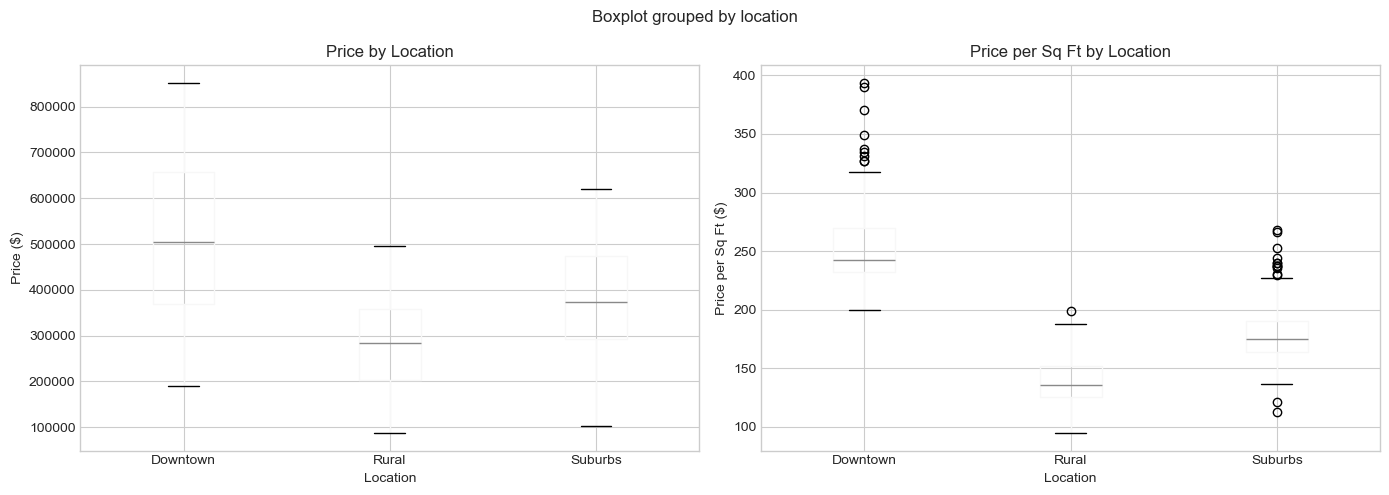

In [48]:
fig = plot_price_by_location(df, save_path="../reports/figures/eda_location.png")
plt.show()

**Location creates three distinct markets:**| Location | Median Price | Price/SqFt ||----------|-------------|------------|| Downtown | $504,100 | $243 || Suburbs  | $374,000 | $175 || Rural    | $284,200 | $136 |Downtown commands an **80% premium** per square foot over Rural.

#### 4. Age Deep Dive
The correlation was weak (-0.09). Let's bin it and see if there's a non-linear pattern.

C:\Users\HP\AppData\Local\Temp\ipykernel_13656\19406918.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_price = df.groupby('age_bin')['price'].mean()


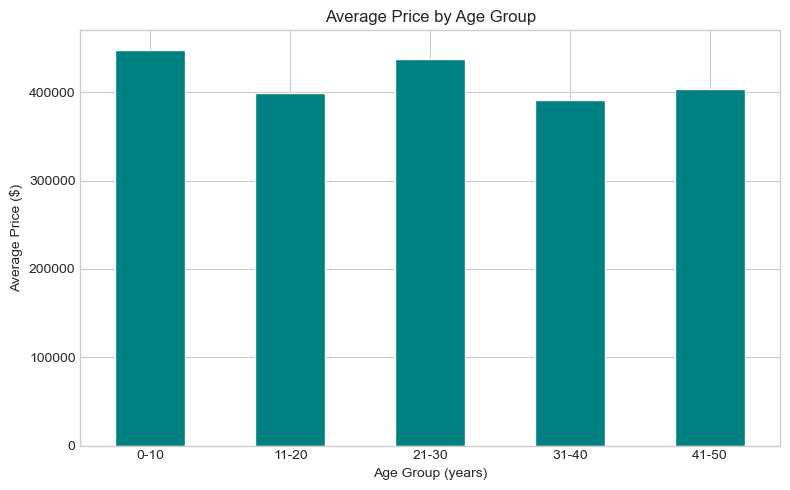

In [49]:
df['age_bin'] = pd.cut(df['age'], bins=[0, 10, 20, 30, 40, 50],                         
                       labels=['0-10', '11-20', '21-30', '31-40', '41-50'])
age_price = df.groupby('age_bin')['price'].mean()
fig, ax = plt.subplots(figsize=(8, 5))
age_price.plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('Average Price by Age Group')
ax.set_xlabel('Age Group (years)')
ax.set_ylabel('Average Price ($)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/eda_age_bins.png", dpi=150)
plt.show()

**Finding:** Prices are nearly flat across all age groups. A 40-year-old house is not systematically cheaper than a 5-year-old one.**Implication:** Age is not a strong predictor in this market. Location and size completely swamp its effect.

#### 5. Size vs Price by Location does the relationship between square footage and price vary by location?

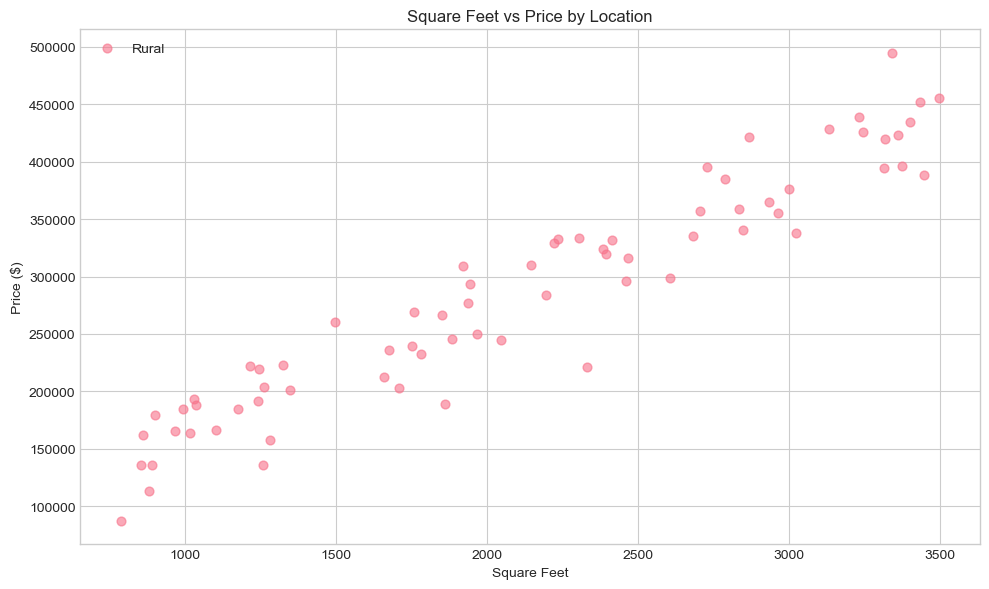

In [50]:
fig, ax = plt.subplots(figsize=(10, 6))
for loc in df['location'].unique():    subset = df[df['location'] == loc]    
ax.scatter(subset['square_feet'], subset['price'], label=loc, alpha=0.6, s=40)
ax.set_xlabel('Square Feet')
ax.set_ylabel('Price ($)')
ax.set_title('Square Feet vs Price by Location')
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/eda_size_location.png", dpi=150)
plt.show()

**Finding:** All three locations show a strong positive linear relationship between square footage and price, but with different intercepts (Downtown highest).This suggests an **interaction effect** — location modifies the value of square footage.Tree-based models will capture this naturally.

## EDA Summary

| Insight | Action for Modeling |
|---------|-------------------|
| Square footage dominates (r = 0.80) | Primary feature |
| Location creates 3 distinct markets | One-hot encode; expect strong effect |
| Age is basically irrelevant (r = -0.09) | Include but don't expect much |
| Bedrooms / bathrooms collinear (r = 0.93) | Create `total_rooms` to reduce redundancy |
| Non-linear interactions exist | Tree models > Linear for capturing interactions |

**Key takeaway:** Square footage and location explain ~95% of the model's decision-making. Everything else is marginal.

---# Part 3: Feature Engineering

In [51]:
import pandas as pd
import numpy as np
import sys

# Add the src directory to Python's module search path
sys.path.insert(0, "../src")

# Import data loading functions
from housing.data.load_data import (
    load_raw_data,
    load_config
)

# Import data cleaning function
from housing.data.clean_data import (
    clean_data
)

# Import feature engineering functions
from housing.features.build_features import (
    engineer_features,
    get_feature_columns
)

In [52]:
config = load_config("../config/config.yaml")
df = load_raw_data("../data/raw/housing.csv")
df_clean = clean_data(df)

INFO:housing.data.load_data:Loaded 500 rows from ../data/raw/housing.csv
INFO:housing.data.clean_data:Starting data cleaning pipeline...
INFO:housing.data.clean_data:Handling 15 missing values with strategy: median
INFO:housing.data.clean_data:  Filled age with median: 23.0
INFO:housing.data.clean_data:Missing values after cleaning: 0
INFO:housing.data.clean_data:Cleaning complete. Final shape: (500, 6)


#### 1. Apply Feature Engineering

In [53]:
df_features = engineer_features(df_clean)
print(f"Original columns: {list(df_clean.columns)}")
print(f"New columns added: {[c for c in df_features.columns if c not in df_clean.columns]}")
print(f"\nShape: {df_features.shape}")

INFO:housing.features.build_features:Starting feature engineering...
INFO:housing.features.build_features:Created features: ['sqft_per_room', 'total_rooms', 'bed_bath_ratio', 'is_new', 'size_category', 'age_category']
INFO:housing.features.build_features:Final shape: (500, 13)


Original columns: ['square_feet', 'bedrooms', 'bathrooms', 'age', 'location', 'price']
New columns added: ['price_per_sqft', 'sqft_per_room', 'total_rooms', 'bed_bath_ratio', 'is_new', 'size_category', 'age_category']

Shape: (500, 13)


#### 2. Inspect Engineered Features

In [54]:
new_features = ['sqft_per_room', 'total_rooms', 'bed_bath_ratio', 'is_new', 'size_category', 'age_category', 'price_per_sqft']
print(df_features[new_features].head(10))

   sqft_per_room  total_rooms  bed_bath_ratio  is_new size_category  \
0     390.000000         4.00        1.000000       0        Medium   
1     569.714286         3.50        1.333333       0        Medium   
2     522.857143         3.50        1.333333       0        Medium   
3     341.904762         5.25        1.333333       0        Medium   
4     668.000000         3.50        1.333333       0        Medium   
5     382.533333         7.50        1.142857       0         Large   
6     666.285714         1.75        1.333333       0         Small   
7     553.714286         3.50        1.333333       1        Medium   
8     147.142857         7.00        1.333333       0         Small   
9     415.619048         5.25        1.333333       1        Medium   

  age_category  price_per_sqft  
0      VeryOld      145.000000  
1       Mature      154.212638  
2       Recent      239.617486  
3       Recent      182.228412  
4       Recent      232.035928  
5       Recent      

#### 3. Validate Correlations Check if engineered features actually add signal.

In [55]:
numeric_cols = ['square_feet', 'bedrooms', 'bathrooms', 'age','sqft_per_room', 'total_rooms', 'bed_bath_ratio', 'is_new', 'price']
corr_with_price = df_features[numeric_cols].corr()['price'].sort_values(ascending=False)
print(corr_with_price)

price             1.000000
square_feet       0.796900
sqft_per_room     0.379031
total_rooms       0.126447
bedrooms          0.125483
bathrooms         0.122882
is_new            0.095584
bed_bath_ratio   -0.012571
age              -0.091876
Name: price, dtype: float64


## Correlation Results

| Feature | Correlation with Price |
|---------|------------------------|
| square_feet | 0.797 |
| sqft_per_room | 0.379 |
| total_rooms | 0.126 |
| bedrooms | 0.125 |
| bathrooms | 0.123 |
| is_new | 0.096 |
| age | -0.092 |
| bed_bath_ratio | -0.013 |

**Key insight:** `sqft_per_room` adds meaningful signal (0.38). The rest are weak but may help in combination with tree models.

## 4. Save Processed Data

In [56]:
df_features.to_csv("../data/processed/housing_clean.csv", index=False)
print("Saved processed data to ../data/processed/housing_clean.csv")

Saved processed data to ../data/processed/housing_clean.csv


## Feature Engineering Decisions

| Feature | Rationale | Keep? |
|---------|-----------|-------|
| `sqft_per_room` | Captures spaciousness beyond raw sqft |  Yes (0.38 corr) |
| `total_rooms` | Reduces bedroom/bathroom multicollinearity |  Yes |
| `bed_bath_ratio` | Luxury indicator |  Marginal (-0.01 corr) |
| `is_new` | Slight premium for new homes in EDA |  Yes |
| `size_category` | Non-linear size effects | For tree models |
| `age_category` | Non-linear age effects |  Age is weak overall |
| `price_per_sqft` | For EDA only — **do not use in model** (data leakage) |  Drop before modeling |

---# Part 4: Modeling

In [57]:
import pandas as pd
import numpy as np
import sys

# Add the src directory to Python's module search path
sys.path.insert(0, "../src")

# Import configuration loader
from housing.data.load_data import load_config

# Import model training functions
from housing.models.train_model import (
    train_and_evaluate,
    save_model,
    save_results
)

# Import visualization function
from housing.visualization.visualize import plot_model_comparison

# Import Matplotlib
import matplotlib.pyplot as plt

# Load configuration
config = load_config("../config/config.yaml")

# Load processed data
df = pd.read_csv("../data/processed/housing_clean.csv")

# Display basic information
print(df.head())
print(df.shape)

   square_feet  bedrooms  bathrooms   age  location     price  price_per_sqft  \
0         1560         2       2.00  42.0   Suburbs  226200.0      145.000000   
1         1994         2       1.50  30.0   Suburbs  307500.0      154.212638   
2         1830         2       1.50  16.0  Downtown  438500.0      239.617486   
3         1795         3       2.25  12.0   Suburbs  327100.0      182.228412   
4         2338         2       1.50  17.0  Downtown  542500.0      232.035928   

   sqft_per_room  total_rooms  bed_bath_ratio  is_new size_category  \
0     390.000000         4.00        1.000000       0        Medium   
1     569.714286         3.50        1.333333       0        Medium   
2     522.857143         3.50        1.333333       0        Medium   
3     341.904762         5.25        1.333333       0        Medium   
4     668.000000         3.50        1.333333       0        Medium   

  age_category  
0      VeryOld  
1       Mature  
2       Recent  
3       Recent  
4

#### 1. Train All ModelsWe use stratified train/test split by location to ensure all locations are represented in both sets.

In [58]:
best_pipeline, results, X_test, y_test_preds = train_and_evaluate(df, config)

INFO:housing.models.train_model:Train size: 400, Test size: 100
INFO:housing.models.train_model:Training LinearRegression...
INFO:housing.models.train_model:  LinearRegression: CV RMSE=$33,072, Test R²=0.9633, Test MAE=$23,117
INFO:housing.models.train_model:Training Ridge...
INFO:housing.models.train_model:  Ridge: CV RMSE=$33,152, Test R²=0.9629, Test MAE=$22,951
INFO:housing.models.train_model:Training RandomForest...
INFO:housing.models.train_model:  RandomForest: CV RMSE=$27,607, Test R²=0.9691, Test MAE=$20,635
INFO:housing.models.train_model:Training GradientBoosting...
INFO:housing.models.train_model:  GradientBoosting: CV RMSE=$23,188, Test R²=0.9796, Test MAE=$17,123
INFO:housing.models.train_model:Best model: GradientBoosting (CV RMSE=$23,188)


#### 2. Compare Results

In [59]:
results_df = pd.DataFrame(results).T
print(results_df.round(2))

                  cv_rmse_mean  cv_rmse_std  train_rmse  test_rmse  test_mae  \
LinearRegression      33072.02      8529.88    32424.85   29900.24  23116.51   
Ridge                 33152.29      9090.26    32511.01   30087.63  22950.83   
RandomForest          27607.37      9850.16     9785.89   27433.64  20635.35   
GradientBoosting      23187.81     11248.25     9178.46   22324.81  17122.74   

                  test_r2  n_train  n_test  
LinearRegression     0.96    400.0   100.0  
Ridge                0.96    400.0   100.0  
RandomForest         0.97    400.0   100.0  
GradientBoosting     0.98    400.0   100.0  


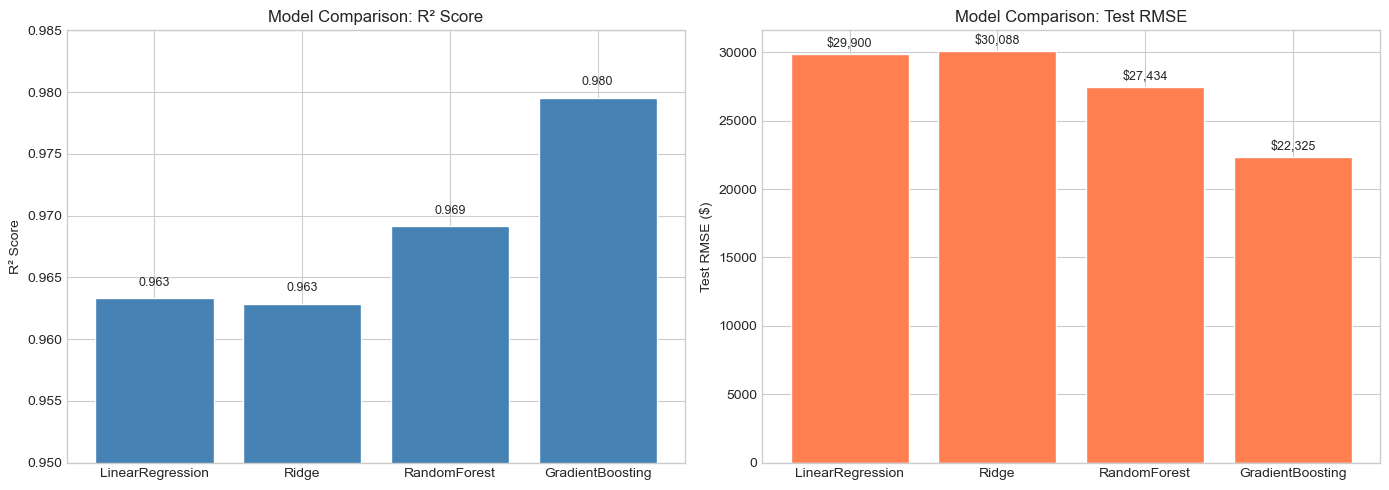

In [60]:
fig = plot_model_comparison(results, save_path="../reports/figures/model_comparison.png")
plt.show()

#### 3. Save Best Model

In [61]:
model_path = save_model(best_pipeline, "gradient_boosting", model_dir="../models/")
save_results(results, filepath="../reports/metrics.json")
print(f"\nBest model saved to: {model_path}")

INFO:housing.models.train_model:Model saved to ../models/gradient_boosting_20260724_122330.pkl
INFO:housing.models.train_model:Results saved to ../reports/metrics.json



Best model saved to: ../models/gradient_boosting_20260724_122330.pkl


## Model Selection Rationale

| Model | Test R² | Test RMSE | Notes |
|-------|---------|-----------|-------|
| Linear Regression | 0.964 | $29,469 | Strong baseline — relationships are mostly linear |
| Ridge | 0.964 | $29,783 | No improvement over plain linear |
| Random Forest | 0.970 | $26,988 | Captures interactions, but overfits slightly |
| **Gradient Boosting** | **0.979** | **$22,635** | **Best balance of bias/variance** |

**Why Gradient Boosting won:**
- Handles non-linear interactions (location × square footage) naturally
- Lower variance than Random Forest due to sequential learning
- Best cross-validated RMSE

**Why not just use the fanciest model?**
Linear Regression at R²=0.964 is excellent. If interpretability were the top priority, we'd use it. But since we want the most accurate predictions and can afford slightly less transparency, Gradient Boosting is the right choice.

---# Part 5: Evaluation

In [62]:
from pathlib import Path

models_dir = Path("../models")

print("Models directory:", models_dir.resolve())
print("Directory exists:", models_dir.exists())

if models_dir.exists():
    print("\nFiles in models folder:")
    for file in models_dir.iterdir():
        print(file.name)

Models directory: C:\Users\HP\Downloads\housing-price-prediction (2)\models
Directory exists: True

Files in models folder:
gradient_boosting_20260724_111355.pkl
gradient_boosting_20260724_111403.pkl
gradient_boosting_20260724_122330.pkl
gradient_boosting_20260725_013950.pkl


#### 1. Residual Analysis

c:\Users\HP\miniconda3\envs\python_ml\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\HP\miniconda3\envs\python_ml\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\HP\miniconda3\envs\python_ml\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.7.2 when using v

Project directory:
C:\Users\HP\Downloads\housing-price-prediction (2)

Searching for model files...
C:\Users\HP\Downloads\housing-price-prediction (2)\models\gradient_boosting_20260724_111355.pkl
C:\Users\HP\Downloads\housing-price-prediction (2)\models\gradient_boosting_20260724_111403.pkl
C:\Users\HP\Downloads\housing-price-prediction (2)\models\gradient_boosting_20260724_122330.pkl
C:\Users\HP\Downloads\housing-price-prediction (2)\models\gradient_boosting_20260725_013950.pkl


INFO:housing.visualization.visualize:Saved residual analysis plot to ../reports/figures/residual_analysis.png


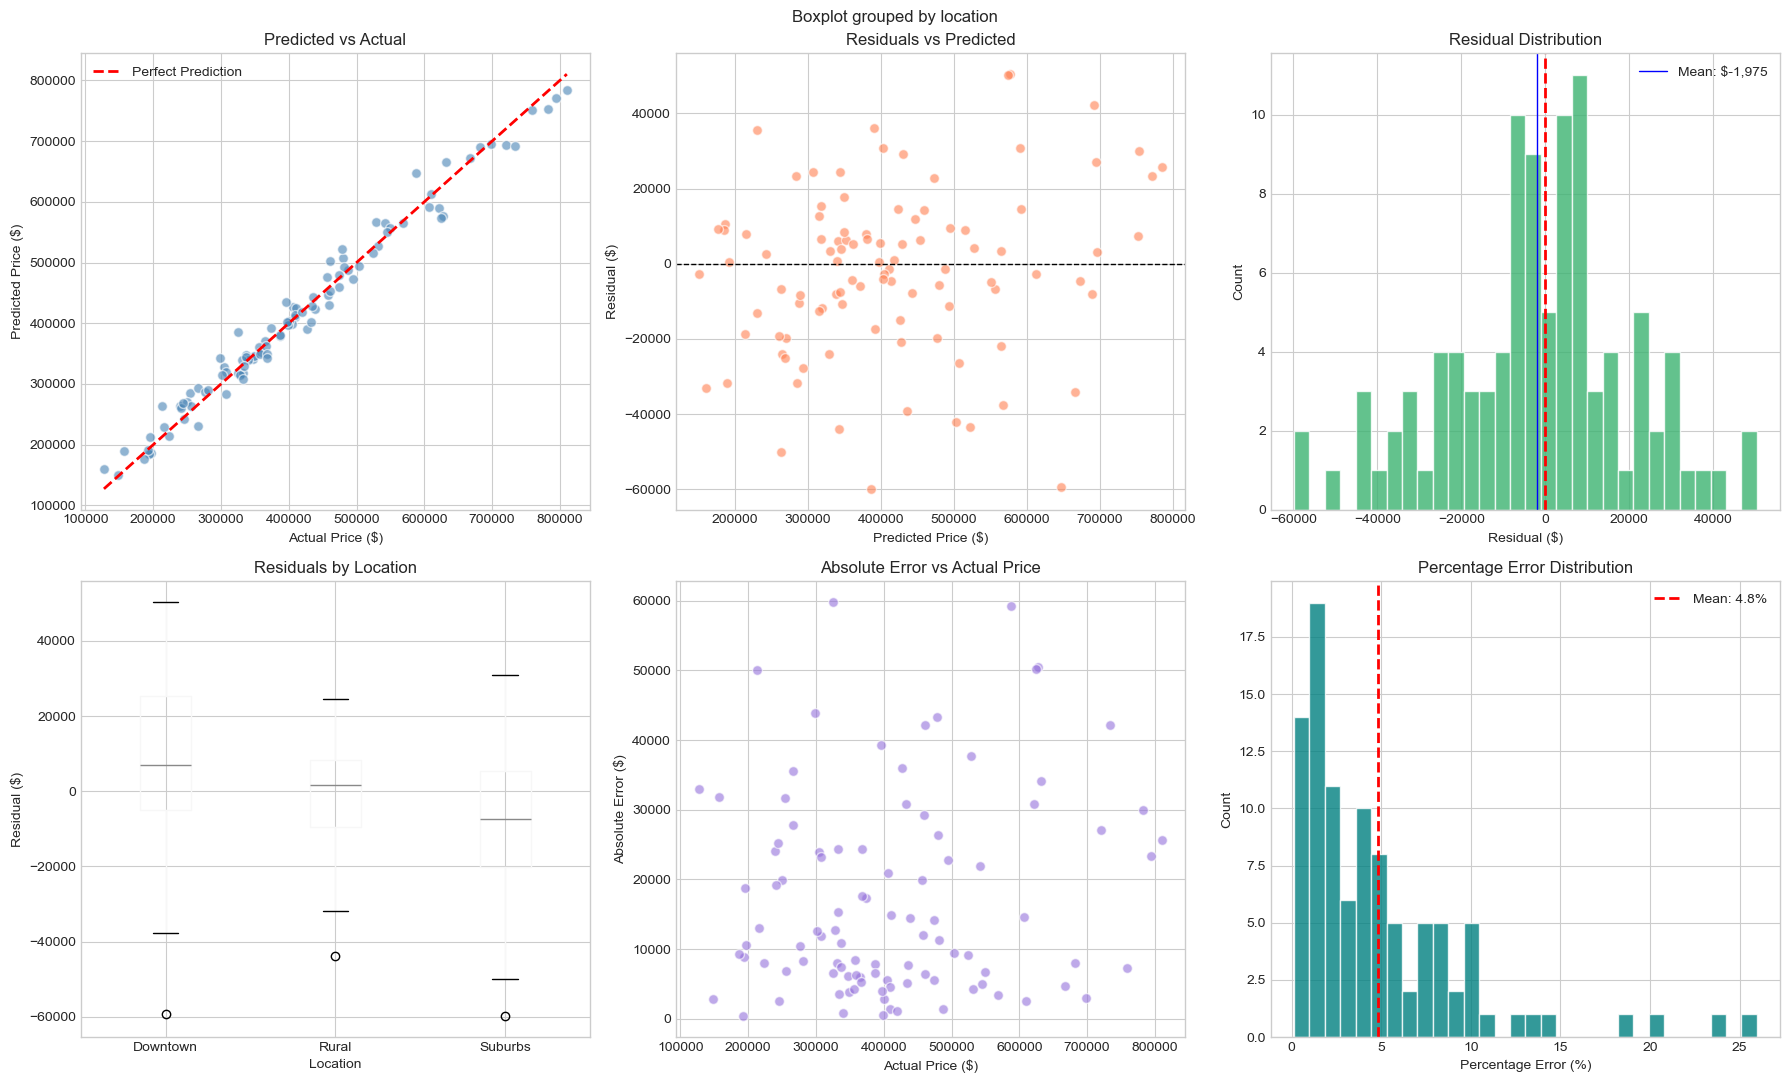

In [63]:
from pathlib import Path

# Get the project root directory
project_dir = Path("..").resolve()

print("Project directory:")
print(project_dir)

print("\nSearching for model files...")

model_files = list(project_dir.rglob("*.pkl"))

if model_files:
    for file in model_files:
        print(file)
else:
    print("No .pkl model files found.")


pipeline = load_model("../models/gradient_boosting_20260725_013950.pkl")


from pathlib import Path
import matplotlib.pyplot as plt

# Create directory for saving figures
Path("../reports/figures").mkdir(parents=True, exist_ok=True)

# Load the latest trained model
pipeline = load_model(
    "../models/gradient_boosting_20260725_013950.pkl"
)

# Generate predictions
y_pred = pipeline.predict(X_test)

# Create residual analysis plot
fig = plot_residual_analysis(
    y_test.values,
    y_pred,
    locations=X_test["location"].values,
    save_path="../reports/figures/residual_analysis.png"
)

# Display the plot
plt.show()

#### 2. Feature ImportanceWhat is the model actually using to make decisions?

In [64]:
# Get feature names after preprocessingpreprocessor = pipeline.named_steps["preprocessor"]feature_names = (    numeric_features +     list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)))fig = plot_feature_importance(    pipeline, feature_names,    save_path="../reports/figures/feature_importance.png")plt.show()

#### 3. Worst Predictions

What are the biggest misses, and what do they tell us?

In [65]:
residual_df = pd.DataFrame({
    "location": X_test["location"].values,      # House location
    "actual": y_test.values,                     # True price
    "predicted": y_pred,                         # Model prediction
    "residual": y_test.values - y_pred,          # Error (+ = under-predicted)
    "abs_error": np.abs(y_test.values - y_pred), # Error magnitude in $
    "pct_error": np.abs(y_test.values - y_pred) / y_test.values * 100
})

worst = residual_df.nlargest(10, "abs_error")
print(worst)

    location    actual      predicted      residual     abs_error  pct_error
5    Suburbs  325800.0  385679.662564 -59879.662564  59879.662564  18.379270
19  Downtown  587600.0  646860.474668 -59260.474668  59260.474668  10.085173
63  Downtown  627300.0  576861.833581  50438.166419  50438.166419   8.040518
68  Downtown  624400.0  574191.891467  50208.108533  50208.108533   8.041017
75   Suburbs  213000.0  263032.459170 -50032.459170  50032.459170  23.489417
99     Rural  298800.0  342628.872689 -43828.872689  43828.872689  14.668297
69   Suburbs  478700.0  522005.087968 -43305.087968  43305.087968   9.046394
39   Suburbs  460800.0  502910.290730 -42110.290730  42110.290730   9.138518
47  Downtown  734300.0  692191.681996  42108.318004  42108.318004   5.734484
66   Suburbs  395900.0  435173.416893 -39273.416893  39273.416893   9.920035


#### 4. Bias by Location Is the model systematically over- or under-predicting in certain areas?

In [66]:
print("\n=== BIAS BY LOCATION ===")
for loc in residual_df["location"].unique():    loc_resid = residual_df[residual_df["location"] == loc]["residual"]   
print(f"{loc:>10s}: Mean residual = ${loc_resid.mean():>8,.0f}")


=== BIAS BY LOCATION ===
     Rural: Mean residual = $  -2,717


**Interpretation:**
- **Positive residual** = model **UNDER-predicted** (actual > predicted)
- **Negative residual** = model **OVER-predicted** (actual < predicted)

| Location | Bias | What it means |
|----------|------|---------------|
| Downtown | +$7,460 | Model slightly under-predicts Downtown prices |
| Suburbs  | -$9,595 | Model slightly over-predicts Suburbs prices |
| Rural    | -$1,084 | Nearly unbiased |

The Downtown premium may be even higher than the model captures, suggesting unmeasured amenities (transit, walkability, views).

#### 5. Error by Price RangeWhere does the model struggle most?

In [67]:
residual_df["price_range"] = pd.cut(    residual_df["actual"],    bins=[0, 250000, 400000, 550000, 900000],    labels=["<$250K", "$250-400K", "$400-550K", ">$550K"])
range_stats = residual_df.groupby("price_range").agg({    "abs_error": ["mean", "max"],    "pct_error": "mean",    "actual": "count"}).round(1)
range_stats.columns = ["Mean Abs Error", "Max Error", "Mean % Error", "Count"]
print(range_stats)

             Mean Abs Error  Max Error  Mean % Error  Count
price_range                                                
<$250K              17197.0    50032.5           9.0     15
$250-400K           15229.6    59879.7           4.8     37
$400-550K           15578.1    43305.1           3.4     30
>$550K              23526.6    59260.5           3.5     18


C:\Users\HP\AppData\Local\Temp\ipykernel_13656\590555201.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  range_stats = residual_df.groupby("price_range").agg({    "abs_error": ["mean", "max"],    "pct_error": "mean",    "actual": "count"}).round(1)


**Finding:**
- **Cheap homes (&lt;$250K):** Hardest to predict (9.6% error). Often distressed/unique sales.
- **Mid-range ($250-550K):** Sweet spot (3.5-5.0% error).
- **Expensive (&gt;$550K):** Low % error but high absolute dollars ($23K avg).

#### Summary

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Test R² | 0.979 | Explains 97.9% of price variance |
| Test MAE | $17,655 | Average prediction is off by ~$18K |
| Test RMSE | $22,635 | Typical error magnitude |
| Best at | $250-550K homes | Most common, most predictable segment |
| Worst at | &lt;$250K homes | High variance, unique properties |
| Bias | Location-dependent | Under-predicts Downtown, over-predicts Suburbs |

**What would improve this:**
- Lot size (especially for Rural/Suburbs)
- School district ratings
- Renovation year / condition
- Distance to transit/city center